In [2]:
#importing Req libraries& their functionalies
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [3]:
data=np.loadtxt('Data/data_w3_ex2.csv', delimiter=',')

In [4]:
data

array([[1.00000000e+03, 1.45728643e+03, 0.00000000e+00],
       [1.04522613e+03, 1.00502513e+03, 0.00000000e+00],
       [1.09045226e+03, 8.54271357e+02, 0.00000000e+00],
       [1.13567839e+03, 2.56281407e+03, 0.00000000e+00],
       [1.18090452e+03, 4.62311558e+03, 0.00000000e+00],
       [1.22613065e+03, 4.97487437e+03, 0.00000000e+00],
       [1.27135678e+03, 2.38693467e+03, 0.00000000e+00],
       [1.31658291e+03, 1.00502513e+02, 0.00000000e+00],
       [1.36180905e+03, 7.28643216e+02, 0.00000000e+00],
       [1.40703518e+03, 4.22110553e+03, 0.00000000e+00],
       [1.45226131e+03, 4.29648241e+03, 0.00000000e+00],
       [1.49748744e+03, 4.52261307e+02, 0.00000000e+00],
       [1.54271357e+03, 2.76381910e+02, 0.00000000e+00],
       [1.58793970e+03, 2.23618090e+03, 0.00000000e+00],
       [1.63316583e+03, 2.76381910e+03, 0.00000000e+00],
       [1.67839196e+03, 2.96482412e+03, 0.00000000e+00],
       [1.72361809e+03, 3.99497487e+03, 0.00000000e+00],
       [1.76884422e+03, 8.79396

In [16]:
x_bc=data[:,:-1]
y_bc=data[:,-1]

y_bc=np.expand_dims(y_bc,axis=1)
print(f"the shape of the inputs x is: {x_bc.shape}")
print(f"the shape of the targets y is: {y_bc.shape}")

the shape of the inputs x is: (200, 2)
the shape of the targets y is: (200, 1)


In [32]:
def plot_bc_dataset(x, y, title):
    y=y.flatten()
    X_pos = x[y == 1]
    X_neg = x[y == 0]

    # Positive examples
    plt.scatter(
        X_pos[:, 0], X_pos[:, 1],
        marker='x',
        color='red',
        label='y=1'
    )

    # Negative examples
    plt.scatter(
        X_neg[:, 0], X_neg[:, 1],
        marker='o',
        facecolors='none',
        edgecolors='dodgerblue',
        label='y=0'
    )

    plt.title(title)
    plt.legend()
    plt.show()

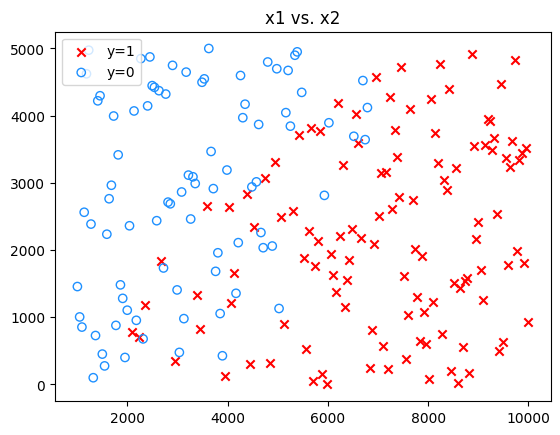

In [33]:
plot_bc_dataset(x=x_bc, y=y_bc, title="x1 vs. x2")

In [34]:
# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables.
x_bc_train, x_, y_bc_train, y_ = train_test_split(x_bc, y_bc, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
x_bc_cv, x_bc_test, y_bc_cv, y_bc_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del x_, y_

print(f"the shape of the training set (input) is: {x_bc_train.shape}")
print(f"the shape of the training set (target) is: {y_bc_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_bc_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_bc_cv.shape}\n")
print(f"the shape of the test set (input) is: {x_bc_test.shape}")
print(f"the shape of the test set (target) is: {y_bc_test.shape}")

the shape of the training set (input) is: (120, 2)
the shape of the training set (target) is: (120, 1)

the shape of the cross validation set (input) is: (40, 2)
the shape of the cross validation set (target) is: (40, 1)

the shape of the test set (input) is: (40, 2)
the shape of the test set (target) is: (40, 1)


In [37]:

# Initialize the class
scaler_linear = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
x_bc_train_scaled = scaler_linear.fit_transform(x_bc_train)
x_bc_cv_scaled = scaler_linear.transform(x_bc_cv)
x_bc_test_scaled = scaler_linear.transform(x_bc_test)


In [38]:
#Neural Networks Models
def build_models():
    tf.keras.utils.set_random_seed(100)
    

    model_1 = Sequential(
        [
            Dense(25, activation = 'relu'),
            Dense(15, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_1'
    )

    model_2 = Sequential(
        [
            Dense(20, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(20, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_2'
    )

    model_3 = Sequential(
        [
            Dense(32, activation = 'relu'),
            Dense(16, activation = 'relu'),
            Dense(8, activation = 'relu'),
            Dense(4, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_3'
    )
    
    model_list = [model_1, model_2, model_3]
    
    return model_list

In [41]:
# Initialize lists that will contain the errors for each model
nn_train_errors=[]
nn_cv_errors=[]

#build models
nn_models_bc=build_models()



#Loop over the models
for model in nn_models_bc:
    #Setup loss and optimizer
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    )

    print(f"Training {model.name}...")

         # Train the model
    model.fit(
            x_bc_train_scaled, y_bc_train,
            epochs=200,
            verbose=0
    )
        
    print("Done!\n")


    #threshold
    threshold=0.5

    

    #record fraction of missclasified examples from training set
    yhat=model.predict(x_bc_train_scaled)
    yhat=tf.nn.sigmoid(yhat)
    yhat=np.where(yhat>=threshold,1,0)
    train_error=np.mean(yhat!=y_bc_train)
    nn_train_errors.append(train_error)

    #record cv mse
    yhat=model.predict(x_bc_cv_scaled)
    yhat=tf.nn.sigmoid(yhat)
    yhat=np.where(yhat>=threshold,1,0)
    cv_error=np.mean(yhat!=y_bc_cv)
    nn_cv_errors.append(cv_error)



# print results
# Print the result
for model_num in range(len(nn_train_errors)):
    print(
        f"Model {model_num+1}: Training Set Classification Error: {nn_train_errors[model_num]:.5f}, " +
        f"CV Set Classification Error: {nn_cv_errors[model_num]:.5f}"
        )

    


    
    

    

Training model_1...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Training model_2...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Training model_3...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Model 1: Training Set Classification Error: 0.03333, CV Set Classification Error: 0.15000
Model 2: Training Set Classification Error: 0.02500, CV Set Classification Error: 0.17500
Model 3: Training Set Classification Error: 0.05000, CV Set Classification Error: 0.10000


In [44]:
model_num = 3

# Compute the test error
yhat = nn_models_bc[model_num-1].predict(x_bc_test_scaled)
yhat = tf.math.sigmoid(yhat)
yhat = np.where(yhat >= threshold, 1, 0)
nn_test_error = np.mean(yhat != y_bc_test)

print(f"Selected Model: {model_num}")
print(f"Training Set Classification Error: {nn_train_errors[model_num-1]:.4f}")
print(f"CV Set Classification Error: {nn_cv_errors[model_num-1]:.4f}")
print(f"Test Set Classification Error: {nn_test_error:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Selected Model: 3
Training Set Classification Error: 0.0500
CV Set Classification Error: 0.1000
Test Set Classification Error: 0.1750
